In [43]:
import numpy as np

NPZ_PATH = "/home/guanghui/DiffODE/algorithm/uncert_out/COVID-JP_uncert_th14_tp14_ALL.npz"  # 改成你的路径
nz = np.load(NPZ_PATH, allow_pickle=True)

print("keys:", nz.files)

y_hat_all    = nz["y_hat_all"]        # (N_all, V, T_p)
uncert_all   = nz["uncert_all"]       # (N_all, V, T_p) —— 当作方差用
y_future_all = nz["y_future_all"]     # (N_all, V, T_p)
label_all    = nz["label_starts_all"] # (N_all,)

meta = nz["meta"].item() if "meta" in nz.files else {}

N_all, V, T_p = y_hat_all.shape
print(f"N_all={N_all}, V={V}, T_p={T_p}")
print("meta:", meta)

keys: ['y_hat_all', 'uncert_all', 'y_future_all', 'label_starts_all', 'label_starts_train', 'label_starts_test', 'meta']
N_all=511, V=47, T_p=14
meta: {'sir_path': '/home/guanghui/DiffODE/data/dataset/COVID-JP/jp20200401_20210921.npy', 'T_h': 14, 'T_p': 14, 'test_start_id': 431, 'alpha_nb': 5.0, 'ut_alpha': 0.2, 'ut_beta': 2.0, 'trim_frac': 0.15, 'max_neg_frac': 0.0, 'clip_nonneg': True, 'calib_s_min': 0.3, 'calib_s_max': 3.0, 'max_inc_val': 1000000.0, 'max_ratio_vs_hist': 100.0, 'compute_sigma_every': 4, 'hess_eps': 0.0005, 'lbfgs_maxiter': 150, 'lbfgs_ftol': 1e-06, 'T': 539, 'V': 47, 'note': "y_hat_all/uncert_all/y_future_all 覆盖所有窗口；label_starts_train / label_starts_test 便于后续切分。不确定性为'数据感知'（使用真实未来构造的参考标签）。"}


In [46]:
# 优先：如果文件里已经有显式的测试索引
if "label_starts_test" in nz.files:
    label_test = nz["label_starts_test"]
    idx_test = np.where(np.isin(label_all, label_test))[0]
else:
    # 其次：用 meta 里记的 test_start_id
    test_start_id = meta.get("test_start_id", None)
    if test_start_id is None:
        print("⚠️ 没有显式测试集信息：先把全部窗口当测试集。")
        idx_test = np.arange(N_all)
    else:
        idx_test = np.where(label_all >= int(test_start_id))[0]

print(f"测试集窗口数: {len(idx_test)}")

测试集窗口数: 94


In [47]:
def mae_rmse(a, b):
    diff = a - b
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff**2)))
    return mae, rmse

# 只看测试集
yh = y_hat_all[idx_test]      # (N_t,V,T_p)
yt = y_future_all[idx_test]   # (N_t,V,T_p)

mae_all, rmse_all = mae_rmse(yh, yt)
print(f"[TEST] Overall MAE={mae_all:.4f}, RMSE={rmse_all:.4f}")

# 每个 step 的 MAE / RMSE（把窗口与节点展平）
mae_step = []
rmse_step = []
for t in range(T_p):
    m, r = mae_rmse(yh[..., t], yt[..., t])  # (N_t,V)
    mae_step.append(m); rmse_step.append(r)

print("Per-step MAE:", ", ".join(f"{x:.2f}" for x in mae_step))
print("Per-step RMSE:", ", ".join(f"{x:.2f}" for x in rmse_step))

[TEST] Overall MAE=104.4831, RMSE=329.6572
Per-step MAE: 93.13, 89.55, 90.14, 91.21, 91.28, 93.06, 96.06, 98.56, 102.73, 110.09, 116.39, 122.85, 130.08, 137.64
Per-step RMSE: 292.72, 282.14, 290.04, 302.57, 307.08, 312.32, 315.79, 317.10, 321.40, 340.44, 357.25, 370.25, 383.28, 396.92


In [48]:
def mae_rmse(a, b):
    diff = a - b
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff**2)))
    return mae, rmse

# 只看测试集
yh = y_hat_all[idx_test]      # (N_t,V,T_p)
yt = y_future_all[idx_test]   # (N_t,V,T_p)

mae_all, rmse_all = mae_rmse(yh, yt)
print(f"[TEST] Overall MAE={mae_all:.4f}, RMSE={rmse_all:.4f}")

# 每个 step 的 MAE / RMSE（把窗口与节点展平）
mae_step = []
rmse_step = []
for t in range(T_p):
    m, r = mae_rmse(yh[..., t], yt[..., t])  # (N_t,V)
    mae_step.append(m); rmse_step.append(r)

print("Per-step MAE:", ", ".join(f"{x:.2f}" for x in mae_step))
print("Per-step RMSE:", ", ".join(f"{x:.2f}" for x in rmse_step))

[TEST] Overall MAE=104.4831, RMSE=329.6572
Per-step MAE: 93.13, 89.55, 90.14, 91.21, 91.28, 93.06, 96.06, 98.56, 102.73, 110.09, 116.39, 122.85, 130.08, 137.64
Per-step RMSE: 292.72, 282.14, 290.04, 302.57, 307.08, 312.32, 315.79, 317.10, 321.40, 340.44, 357.25, 370.25, 383.28, 396.92


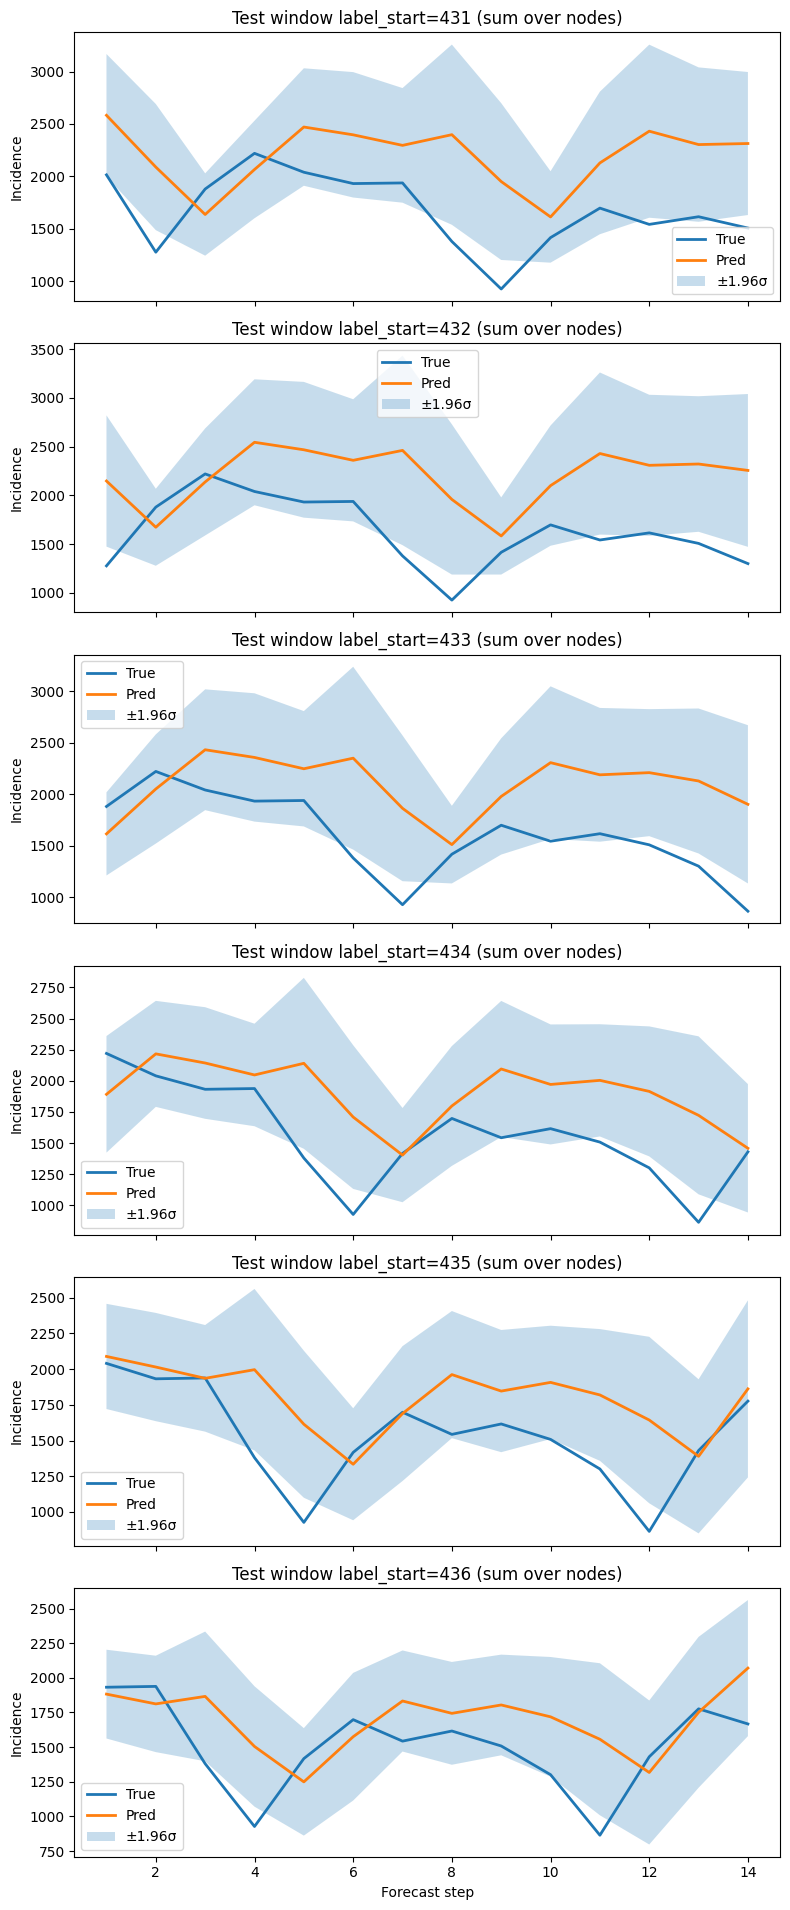

In [51]:
import matplotlib.pyplot as plt

def safe_sqrt(x):
    return np.sqrt(np.clip(x, 0.0, None))

T_show = T_p
t = np.arange(1, T_show+1)

# 选几个测试窗口看看
show_k = min(6, len(idx_test))
sel = idx_test[:show_k]

fig, axes = plt.subplots(show_k, 1, figsize=(8, 3.2*show_k), sharex=True)
if show_k == 1:
    axes = [axes]

for ax, wi in zip(axes, sel):
    y_true = y_future_all[wi].sum(0)        # (T_p,) 全节点求和
    y_pred = y_hat_all[wi].sum(0)
    varsum = uncert_all[wi].sum(0)          # 方差假设独立可加（近似）
    std = safe_sqrt(varsum)
    upper = y_pred + 1.96*std
    lower = y_pred - 1.96*std

    ax.plot(t, y_true, label="True", lw=2)
    ax.plot(t, y_pred, label="Pred", lw=2)
    ax.fill_between(t, lower, upper, alpha=0.25, label="±1.96σ")

    ax.set_title(f"Test window label_start={int(label_all[wi])} (sum over nodes)")
    ax.set_ylabel("Incidence")
    ax.legend()

axes[-1].set_xlabel("Forecast step")
plt.tight_layout()
plt.show()

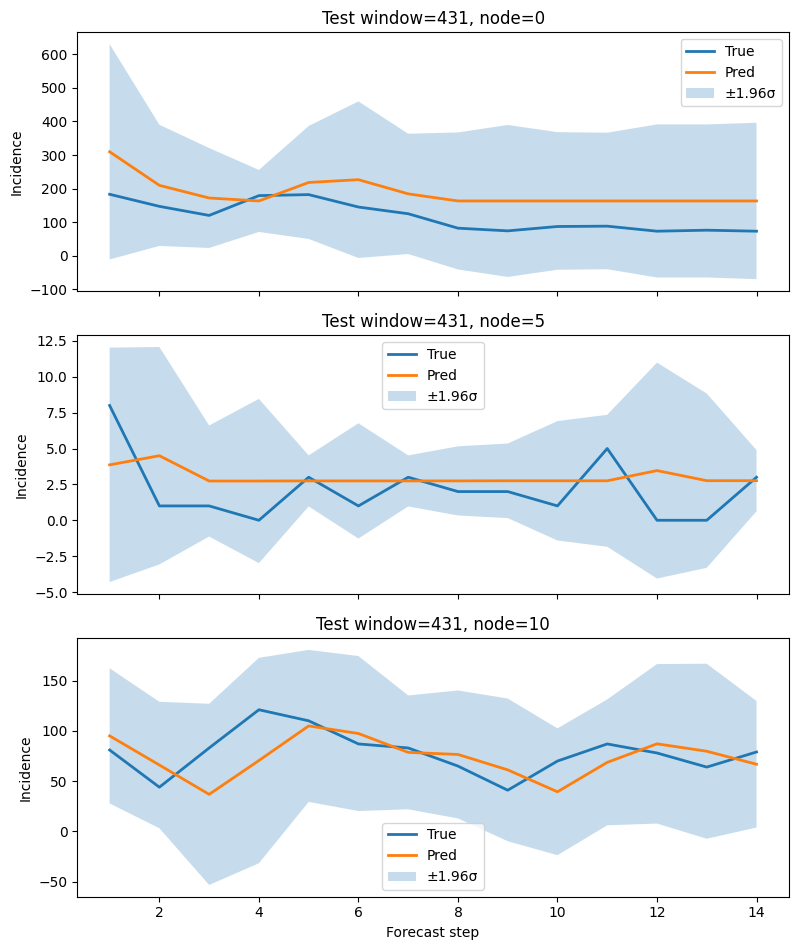

In [50]:
# 指定一个窗口和几个节点
win_id = int(sel[0])  # 用上面挑的第一个
nodes = [0, 5, 10]    # 改成你想看的

fig, axes = plt.subplots(len(nodes), 1, figsize=(8, 3.2*len(nodes)), sharex=True)
if len(nodes) == 1:
    axes = [axes]

for ax, v in zip(axes, nodes):
    y_true = y_future_all[win_id, v]   # (T_p,)
    y_pred = y_hat_all[win_id, v]
    var_v  = uncert_all[win_id, v]
    std = safe_sqrt(var_v)
    upper = y_pred + 1.96*std
    lower = y_pred - 1.96*std

    ax.plot(t, y_true, label="True", lw=2)
    ax.plot(t, y_pred, label="Pred", lw=2)
    ax.fill_between(t, lower, upper, alpha=0.25, label="±1.96σ")

    ax.set_title(f"Test window={int(label_all[win_id])}, node={v}")
    ax.set_ylabel("Incidence")
    ax.legend()

axes[-1].set_xlabel("Forecast step")
plt.tight_layout()
plt.show()

In [52]:
import pandas as pd

df = pd.DataFrame({
    "step": np.arange(1, T_p+1),
    "mae": mae_step,
    "rmse": rmse_step,
})
display(df)
# df.to_csv("./metrics_test_per_step.csv", index=False)

# 整体一行
df_all = pd.DataFrame([{"mae_overall": mae_all, "rmse_overall": rmse_all, "num_windows": len(idx_test)}])
display(df_all)

,step,mae,rmse
0,1,93.130600,292.720655
1,2,89.551095,282.136485
2,3,90.135631,290.036304
3,4,91.211814,302.573931
4,5,91.278793,307.084004
5,6,93.055864,312.321339
6,7,96.061572,315.786825
7,8,98.556367,317.099753
8,9,102.732671,321.401920
9,10,110.093656,340.437444


,mae_overall,rmse_overall,num_windows
0,104.483086,329.657203,94


In [53]:
import numpy as np

# 1) 取测试集的窗口（如果你想用全体窗口，把 idx 换成 np.arange(len(label_starts_all))）
idx = idx_test

yh = y_hat_all[idx]      # (N_sel, V, T_p)
yt = y_future_all[idx]   # (N_sel, V, T_p)
err = yh - yt            # (N_sel, V, T_p)

# 2) “每个窗口/点/时间”的绝对误差与平方误差（保留最细粒度）
mae_win_node_time  = np.abs(err)   # (N_sel, V, T_p)
mse_win_node_time  = err**2        # (N_sel, V, T_p)

# 3) 对窗口求平均，得到“每个点×每个时间步”的 MAE / RMSE
mae_node_time  = mae_win_node_time.mean(axis=0)                 # (V, T_p)
rmse_node_time = np.sqrt(mse_win_node_time.mean(axis=0))        # (V, T_p)

print("mae_node_time shape:", mae_node_time.shape, "(V, T_p)")
print("rmse_node_time shape:", rmse_node_time.shape, "(V, T_p)")

# 4)（可选）整体一个标量，检查一下范围
mae_overall  = float(mae_node_time.mean())
rmse_overall = float(rmse_node_time.mean())
print(f"Overall (avg over V,T)  MAE={mae_overall:.4f},  RMSE={rmse_overall:.4f}")

mae_node_time shape: (47, 14) (V, T_p)
rmse_node_time shape: (47, 14) (V, T_p)
Overall (avg over V,T)  MAE=104.4831,  RMSE=182.0019


In [54]:
# 每个“时间步”的 MAE/RMSE（把窗口和节点都平均掉）
mae_per_step  = mae_win_node_time.mean(axis=(0,1))            # (T_p,)
rmse_per_step = np.sqrt(mse_win_node_time.mean(axis=(0,1)))   # (T_p,)
print("mae_per_step:", mae_per_step)
print("rmse_per_step:", rmse_per_step)

# 每个“窗口”的 MAE/RMSE（把节点和时间都平均掉）
mae_per_window  = mae_win_node_time.mean(axis=(1,2))                    # (N_sel,)
rmse_per_window = np.sqrt(mse_win_node_time.mean(axis=(1,2)))           # (N_sel,)
print("mae_per_window (first 10):", mae_per_window[:10])
print("rmse_per_window (first 10):", rmse_per_window[:10])

mae_per_step: [ 93.13060023  89.55109469  90.13563108  91.21181407  91.2787927
  93.05586443  96.0615718   98.55636732 102.73267071 110.09365573
 116.38949502 122.8454406  130.07981135 137.64039212]
rmse_per_step: [292.72065545 282.13648505 290.03630429 302.57393056 307.084004
 312.32133911 315.78682492 317.09975275 321.40191968 340.43744435
 357.24939829 370.24665023 383.28158282 396.9202331 ]
mae_per_window (first 10): [17.31925458 18.04111684 16.82161998 14.21858353 13.14929981 12.24158489
 11.40816078 10.73145785 10.55752556 10.9562101 ]
rmse_per_window (first 10): [43.08037252 47.45651547 43.78282318 33.85561296 30.37071977 27.45544163
 25.22194335 23.86620519 23.15916566 23.99527093]


In [31]:
f=nz
y_hat_all = f["y_hat_all"]         # (N_all, V, T_p)
y_future_all = f["y_future_all"]   # (N_all, V, T_p)
label_starts_all = f["label_starts_all"]


# 计算 MAE / RMSE per window
mae_per_window = np.mean(np.abs(y_hat_all - y_future_all), axis=(1,2))  # (N_all,)
rmse_per_window = np.sqrt(np.mean((y_hat_all - y_future_all)**2, axis=(1,2)))

# 找到最大的 top-k 窗口
k = 5
worst_mae_idx = np.argsort(-mae_per_window)[:k]
worst_rmse_idx = np.argsort(-rmse_per_window)[:k]

print("Top-k windows with largest MAE:")
for i in worst_mae_idx:
    print(f"  window {i} (label_start={label_starts_all[i]}): MAE={mae_per_window[i]:.2f}, RMSE={rmse_per_window[i]:.2f}")

print("\nTop-k windows with largest RMSE:")
for i in worst_rmse_idx:
    print(f"  window {i} (label_start={label_starts_all[i]}): MAE={mae_per_window[i]:.2f}, RMSE={rmse_per_window[i]:.2f}")

Top-k windows with largest MAE:
  window 302 (label_start=316): MAE=354609930736.03, RMSE=8227895185745.88
  window 203 (label_start=217): MAE=202634653158.36, RMSE=4701654391861.67
  window 161 (label_start=175): MAE=185748058095.08, RMSE=4309849859200.03
  window 205 (label_start=219): MAE=135089496857.03, RMSE=3134436261236.30
  window 164 (label_start=178): MAE=118203364759.68, RMSE=2742631728582.14

Top-k windows with largest RMSE:
  window 302 (label_start=316): MAE=354609930736.03, RMSE=8227895185745.88
  window 203 (label_start=217): MAE=202634653158.36, RMSE=4701654391861.67
  window 161 (label_start=175): MAE=185748058095.08, RMSE=4309849859200.03
  window 205 (label_start=219): MAE=135089496857.03, RMSE=3134436261236.30
  window 164 (label_start=178): MAE=118203364759.68, RMSE=2742631728582.14


IndexError: index 302 is out of bounds for axis 0 with size 94

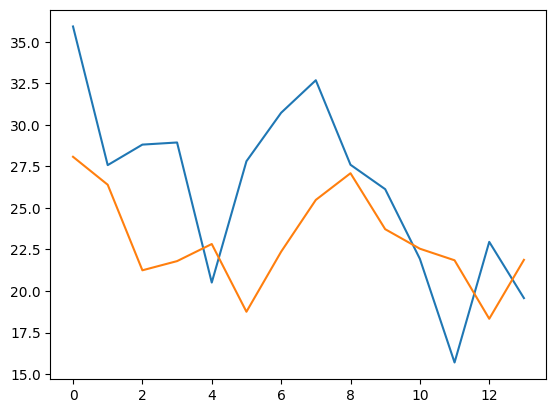

In [55]:
import matplotlib.pyplot as plt

win_id = worst_rmse_idx[0]  # 举例选 RMSE 最大的窗口
y_pred = y_hat_all[win_id]      # (V,T_p)
y_true = y_future_all[win_id]   # (V,T_p)

# 这里先对所有节点取平均（也可以挑单个节点看）
plt.plot(y_true.mean(axis=0), label="True (avg)")
plt.plot(y_pred.mean(axis=0), label="Pred (avg)")
plt.title(f"Window {win_id}, start={label_starts_all[win_id]}\nMAE={mae_per_window[win_id]:.2f}, RMSE={rmse_per_window[win_id]:.2f}")
plt.legend()
plt.show()

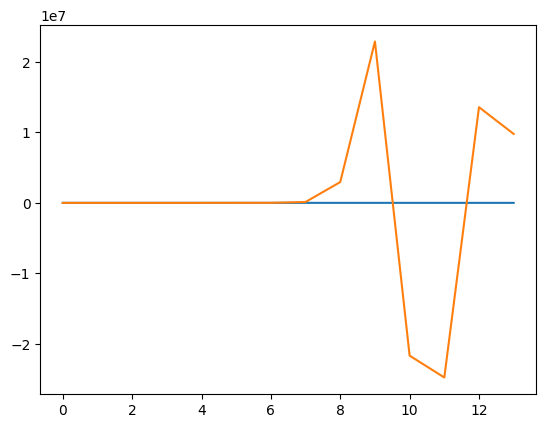

In [15]:
v = np.argmax(np.abs(y_hat_all[win_id] - y_future_all[win_id]).sum(axis=1))
plt.plot(y_future_all[win_id,v], label="True")
plt.plot(y_hat_all[win_id,v], label="Pred")

In [56]:
y_future_all[win_id,v]

array([172., 124., 163., 131.,  94., 114., 130., 210., 141., 121.,  84.,
       101., 105.,  59.])

In [57]:
y_hat_all[win_id,v]

array([145.88279602, 151.52374961, 111.49486592, 149.56257543,
       122.69687254,  89.86810731, 111.21804327, 129.42805883,
       213.35977224, 146.22738007, 128.07791418,  90.76522591,
       111.37758394, 118.16726917])

Shapes -> y_hat_all: (511, 47, 14), y_true_all: (511, 47, 14), V=47, T_p=14
Top-10 windows by RMSE:
  win_id= 502, start=516, MAE=437.87, RMSE=728.40
  win_id= 481, start=495, MAE=247.58, RMSE=726.11
  win_id= 503, start=517, MAE=409.20, RMSE=703.45
  win_id= 482, start=496, MAE=257.83, RMSE=685.80
  win_id= 501, start=515, MAE=381.20, RMSE=631.39
  win_id= 504, start=518, MAE=334.73, RMSE=626.55
  win_id= 497, start=511, MAE=294.83, RMSE=618.31
  win_id= 498, start=512, MAE=314.13, RMSE=616.26
  win_id= 496, start=510, MAE=277.92, RMSE=606.92
  win_id= 500, start=514, MAE=347.03, RMSE=599.01

Top-10 windows by anomaly count:
  win_id= 128, start=142, anom_total=5, MAE=10.8, RMSE=25.1
  win_id=   7, start=21, anom_total=5, MAE=21.4, RMSE=68.1
  win_id=   8, start=22, anom_total=4, MAE=17.1, RMSE=55.4
  win_id=   9, start=23, anom_total=4, MAE=13.2, RMSE=42.9
  win_id=   5, start=19, anom_total=3, MAE=23.3, RMSE=67.6
  win_id=   6, start=20, anom_total=3, MAE=24.2, RMSE=74.6
  win_id= 2

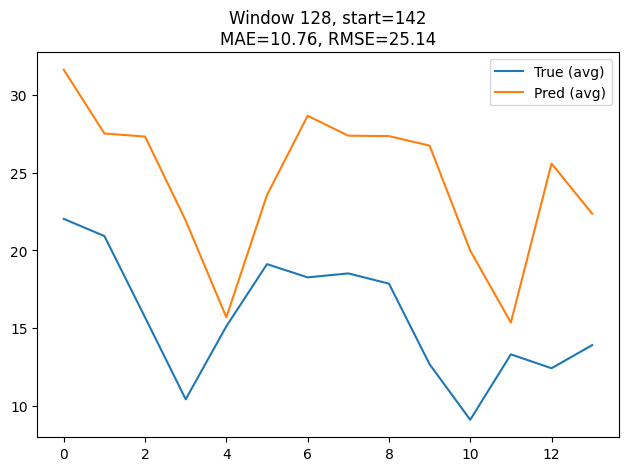

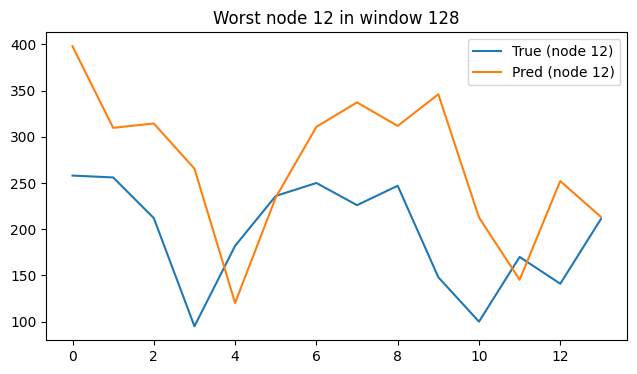

In [58]:
y_hat_all = nz["y_hat_all"]          # (N_all, V, T_p)
label_starts_all = nz["label_starts_all"]  # (N_all,)

# y_future_all 可能不一定有；如果有，用它；如果没有就尝试从 SIR 重建（这里先判空）
y_true_all = nz["y_future_all"] if "y_future_all" in nz else None
if y_true_all is None:
    raise RuntimeError("此文件里没有 y_future_all，请换成包含 ground-truth 的 npz（或提供 SIR 以重建）。")

N_all, V, T_p = y_hat_all.shape
print(f"Shapes -> y_hat_all: {y_hat_all.shape}, y_true_all: {y_true_all.shape}, V={V}, T_p={T_p}")

# ==== 3) 每窗口、每节点、每时间的误差 ====
err = y_hat_all - y_true_all                   # (N,V,T)
abs_err = np.abs(err)
sq_err = err**2

# 每窗口 MAE/RMSE（对 V 和 T 取均值）
mae_per_win  = abs_err.mean(axis=(1,2))
rmse_per_win = np.sqrt(sq_err.mean(axis=(1,2)))

print("Top-10 windows by RMSE:")
topk = np.argsort(-rmse_per_win)[:10]
for k in topk:
    print(f"  win_id={k:4d}, start={int(label_starts_all[k])}, MAE={mae_per_win[k]:.2f}, RMSE={rmse_per_win[k]:.2f}")

# 每(窗口,节点) RMSE（对时间取均值）
rmse_per_win_node = np.sqrt(sq_err.mean(axis=2))   # (N,V)

# ==== 4) 异常检测规则 ====
# 你可以调整这些阈值
ABS_BIG = 1e5          # 绝对值阈：预测达到10万以上就很可疑（根据你图里的数量级设定）
RATIO_BIG = 50.0       # 比例阈：|pred| / (true+1) > 50
TRUE_SMALL = 200.0     # 真实值很小，却预测超大
EPS = 1.0              # 防止除零

y_pred = y_hat_all
y_true = y_true_all

mask_abs_big   = (np.abs(y_pred) > ABS_BIG) & (y_true < TRUE_SMALL)
mask_ratio_big = (np.abs(y_pred) / (y_true + EPS) > RATIO_BIG)
mask_negative  = (y_pred < 0) & (y_true >= 0)     # 理论上 incidence 不应为负

# 汇总每窗口的异常计数
anoms_per_win = {
    "abs_big":   mask_abs_big.sum(axis=(1,2)),
    "ratio_big": mask_ratio_big.sum(axis=(1,2)),
    "negative":  mask_negative.sum(axis=(1,2)),
}
anoms_total = anoms_per_win["abs_big"] + anoms_per_win["ratio_big"] + anoms_per_win["negative"]

print("\nTop-10 windows by anomaly count:")
top_anom = np.argsort(-anoms_total)[:10]
for k in top_anom:
    print(f"  win_id={k:4d}, start={int(label_starts_all[k])}, "
          f"anom_total={int(anoms_total[k])}, "
          f"MAE={mae_per_win[k]:.1f}, RMSE={rmse_per_win[k]:.1f}")

# ==== 5) 把异常点列出来（少量示例） ====
def list_anomaly_points(max_list=20):
    idxs = np.argwhere(mask_abs_big | mask_ratio_big | mask_negative)
    # 排序：优先按 |误差| 大的来
    scores = np.abs(err[mask_abs_big | mask_ratio_big | mask_negative])
    order = np.argsort(-scores)
    idxs = idxs[order][:max_list]
    rows = []
    for (w, v, t) in idxs:
        rows.append({
            "win_id": int(w),
            "start": int(label_starts_all[w]),
            "node": int(v),
            "t": int(t),
            "y_true": float(y_true[w,v,t]),
            "y_pred": float(y_pred[w,v,t]),
            "abs_err": float(abs_err[w,v,t]),
            "flags": ",".join([
                "ABS" if mask_abs_big[w,v,t] else "",
                "RATIO" if mask_ratio_big[w,v,t] else "",
                "NEG" if mask_negative[w,v,t] else "",
            ]).strip(",")
        })
    return rows

rows = list_anomaly_points(max_list=25)
print("\nSample anomaly points (top by |error|):")
for r in rows:
    print(r)

# ==== 6) 快速可视化：画某个窗口的 平均曲线 & 最差节点 ====
def plot_window(win_id, show_worst_node=True):
    y_t = y_true[win_id]      # (V,T)
    y_p = y_pred[win_id]      # (V,T)
    mae = np.abs(y_p - y_t).mean()
    rmse = np.sqrt(((y_p - y_t)**2).mean())

    plt.figure(figsize=(7.5,5))
    plt.plot(y_t.mean(axis=0), label="True (avg)")
    plt.plot(y_p.mean(axis=0), label="Pred (avg)")
    plt.title(f"Window {win_id}, start={int(label_starts_all[win_id])}\n"
              f"MAE={mae:.2f}, RMSE={rmse:.2f}")
    plt.legend()
    plt.show()

    if show_worst_node:
        v_worst = np.argmax(np.sqrt(((y_p - y_t)**2).mean(axis=1)))  # 按节点RMSE找最差
        plt.figure(figsize=(7.5,4))
        plt.plot(y_t[v_worst], label=f"True (node {v_worst})")
        plt.plot(y_p[v_worst], label=f"Pred (node {v_worst})")
        plt.title(f"Worst node {v_worst} in window {win_id}")
        plt.legend()
        plt.show()

# 例如：画“异常最多”的窗口
if len(top_anom) > 0:
    plot_window(int(top_anom[0]))

In [59]:
nz = np.load(NPZ_PATH, allow_pickle=True)
y_hat_all = nz["y_hat_all"]
y_true_all = nz["y_future_all"]

N, V, T = y_hat_all.shape

# ==== 定义阈值 ====
ABS_BIG = 1e5
RATIO_BIG = 50.0
TRUE_SMALL = 200.0
EPS = 1.0

# ==== 三类爆炸情况 ====
mask_abs_big   = (np.abs(y_hat_all) > ABS_BIG) & (y_true_all < TRUE_SMALL)
mask_ratio_big = (np.abs(y_hat_all) / (y_true_all + EPS) > RATIO_BIG)
mask_negative  = (y_hat_all < 0) & (y_true_all >= 0)

# ==== 统计 ====
n_abs   = int(mask_abs_big.sum())
n_ratio = int(mask_ratio_big.sum())
n_neg   = int(mask_negative.sum())

total_explosions = n_abs + n_ratio + n_neg
total_points = N * V * T

print(f"Total points: {total_points}")
print(f"Explosions (abs>1e5): {n_abs}")
print(f"Explosions (ratio>50): {n_ratio}")
print(f"Explosions (negative): {n_neg}")
print(f"Total explosions: {total_explosions}")
print(f"Fraction: {total_explosions/total_points:.6%}")

Total points: 336238
Explosions (abs>1e5): 0
Explosions (ratio>50): 79
Explosions (negative): 0
Total explosions: 79
Fraction: 0.023495%


In [60]:
data=nz
y_hat_all = data["y_hat_all"]       # (N_all, V, T_p)
label_starts_all = data["label_starts_all"]  # (N_all,)
y_future_all = data.get("y_future_all", None)  # 如果有保存未来真值

N_all, V, T_p = y_hat_all.shape

explosions = []

for win_id in range(N_all):
    for v in range(V):
        y_hat = y_hat_all[win_id, v]
        if y_future_all is not None:
            y_true = y_future_all[win_id, v]
        else:
            # 没有存未来真值时，只能用阈值判断
            y_true = np.ones_like(y_hat)

        for t in range(T_p):
            yh, yt = y_hat[t], y_true[t]
            cond_abs = abs(yh) > 1e5 and yt < 200
            cond_ratio = yt > 0 and abs(yh) / (yt + 1e-6) > 50
            cond_neg = yh < 0
            if cond_abs or cond_ratio or cond_neg:
                explosions.append((win_id, v, t, yh, yt))

print(f"Total explosions: {len(explosions)}")

# 按 |预测值| 大小排序
explosions_sorted = sorted(explosions, key=lambda x: abs(x[3]), reverse=True)

# 打印 top-10
print("Top-10 explosions (win_id, node, time, y_hat, y_true):")
for e in explosions_sorted[:10]:
    print(e)

Total explosions: 99
Top-10 explosions (win_id, node, time, y_hat, y_true):
(502, 15, 13, 582.5550152928047, 6.0)
(503, 15, 12, 497.12733715513536, 6.0)
(115, 44, 11, 230.08280067504904, 3.0)
(114, 44, 12, 205.54803203355854, 3.0)
(116, 44, 10, 188.11573503224463, 3.0)
(233, 37, 13, 175.35681620998884, 2.0)
(234, 37, 12, 169.48368758681175, 2.0)
(117, 44, 9, 154.3504536238505, 3.0)
(9, 33, 8, 131.13094131050812, 1.0)
(9, 33, 5, 122.50643952459858, 1.0)


In [61]:
NPZ_PATH = "COVID-US_uncert_th14_tp14_ALL.npz"  # 你的文件名
ABS_TH    = 1e5      # 绝对值阈值
RATIO_TH  = 50.0     # 相对比率阈值
TRUE_CUT  = 200.0    # 仅当真值较小才用绝对阈值

# ==== 读取 ====
z = nz
y_hat_all = z["y_hat_all"]                     # (N_all, V, T_p)
label_starts_all = z["label_starts_all"]       # (N_all,)
y_future_all = z.get("y_future_all", None)     # (N_all, V, T_p) 可能存在

N_all, V, T_p = y_hat_all.shape
total_points = N_all * V * T_p

# ==== 条件 ====
YH = y_hat_all
if y_future_all is not None:
    YT = y_future_all
else:
    # 若没有真值，只能退化为阈值与负值判断
    YT = np.ones_like(YH)

cond_abs   = (np.abs(YH) > ABS_TH) & (YT < TRUE_CUT)
cond_ratio = (YT > 0) & (np.abs(YH) / (YT + 1e-6) > RATIO_TH)
cond_neg   = (YH < 0)

mask = cond_abs | cond_ratio | cond_neg
num_expl = int(mask.sum())

print(f"Total points: {total_points}")
print(f"Explosions (any cond): {num_expl}  -> fraction = {num_expl/total_points:.4%}")

# ==== 1) 按 node 统计 ====
count_per_node = mask.sum(axis=(0,2))  # (V,)
top_nodes_idx = np.argsort(-count_per_node)  # 降序
print("\nTop-20 nodes by explosion count:")
for i in top_nodes_idx[:20]:
    print(f"node={i:>3d}  count={int(count_per_node[i])}")

# ==== 2) 按 window 统计 ====
count_per_win = mask.sum(axis=(1,2))   # (N_all,)
top_wins_idx = np.argsort(-count_per_win)
print("\nTop-20 windows by explosion count:")
for wi in top_wins_idx[:20]:
    print(f"win_id={wi:>4d}  start_idx={int(label_starts_all[wi])}  count={int(count_per_win[wi])}")

# ==== 3) (node, start_idx) 二元对：统计每个对儿里有多少个 time-step 爆炸 ====
# 先把 time 维度合并
pair_counts = mask.sum(axis=2)     # (N_all, V) —— 每个 (win_id, node) 爆炸的时间步数
wi_idx, v_idx = np.where(pair_counts > 0)
pairs = [(int(v), int(label_starts_all[wi]), int(pair_counts[wi, v])) for wi, v in zip(wi_idx, v_idx)]

# 按爆炸次数降序
pairs_sorted = sorted(pairs, key=lambda x: -x[2])

print("\nTop-30 (node, start_idx) pairs by explosion time-steps:")
for v, start_idx, cnt in pairs_sorted[:30]:
    print(f"node={v:>3d}, start_idx={start_idx:>4d}, exploded_steps={cnt}")

Total points: 336238
Explosions (any cond): 99  -> fraction = 0.0294%

Top-20 nodes by explosion count:
node= 33  count=26
node= 20  count=13
node= 37  count=10
node= 41  count=8
node= 44  count=6
node= 39  count=6
node= 42  count=4
node= 21  count=4
node= 35  count=3
node= 16  count=3
node= 15  count=3
node=  9  count=3
node=  8  count=3
node= 17  count=2
node= 31  count=1
node= 34  count=1
node= 30  count=1
node=  1  count=1
node= 19  count=1
node= 32  count=0

Top-20 windows by explosion count:
win_id= 117  start_idx=131  count=6
win_id=   5  start_idx=19  count=3
win_id= 118  start_idx=132  count=3
win_id= 116  start_idx=130  count=3
win_id= 115  start_idx=129  count=3
win_id= 114  start_idx=128  count=3
win_id=   0  start_idx=14  count=2
win_id= 279  start_idx=293  count=2
win_id= 278  start_idx=292  count=2
win_id= 172  start_idx=186  count=2
win_id= 162  start_idx=176  count=2
win_id= 120  start_idx=134  count=2
win_id= 119  start_idx=133  count=2
win_id= 113  start_idx=127  cou

In [33]:
nz

NpzFile './uncert_out/COVID-US_uncert_th14_tp14_ALL.npz' with keys: y_hat_all, uncert_all, y_future_all, label_starts_all, label_starts_train...